# 01 — Os datasets

**Etapa 7 do roteiro.** Antes de qualquer coisa quântica, olhar a matéria-prima.

Nada neste notebook é quântico. Aqui só existem números clássicos: pontos num plano com
um rótulo 0 ou 1. A transformação $x \mapsto \psi(x)$ vem depois, em `embeddings.py`.

O que interessa ver aqui é a **geometria da fronteira** de cada dataset — porque a tese
central do TCC é que codificações diferentes lidam melhor ou pior com geometrias diferentes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

from tccqml.config import PADRAO
from tccqml.data import load_dataset

# raiz do repo, para salvar figuras em results/figures/
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# PNGs de exploração ficam separados dos PDFs oficiais (results/figures/),
# para não haver dúvida sobre qual figura o TCC usa.
FIGS = RAIZ / "results" / "figures" / "notebook"
FIGS.mkdir(parents=True, exist_ok=True)

NOMES = ["xor", "moons", "circles"]

In [2]:
# n_samples e noise vêm do protocolo, não de literais repetidos aqui.
datasets = {n: load_dataset(n, seed=PADRAO.seed) for n in NOMES}

for nome, ds in datasets.items():
    print(f"{nome:8s} treino={len(ds.X_train):4d}  teste={len(ds.X_test):3d}  features={ds.n_features}")

xor      treino= 210  teste= 90  features=2
moons    treino= 210  teste= 90  features=2
circles  treino= 210  teste= 90  features=2


## Os três problemas, lado a lado

Eixos em radianos: os dados já saem do `load_dataset` normalizados para $[0, \pi]$,
prontos para virar ângulos de rotação.

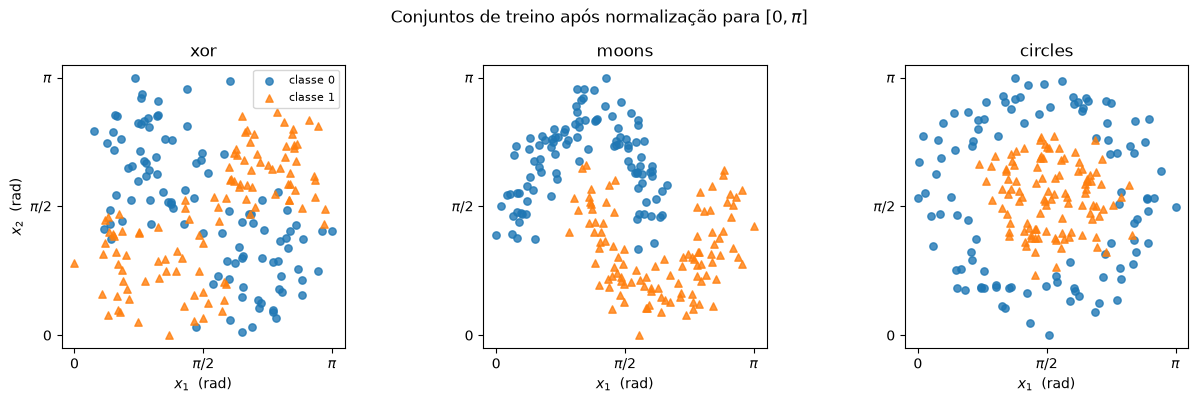

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, nome in zip(axes, NOMES):
    ds = datasets[nome]
    for classe, marcador in [(0, "o"), (1, "^")]:
        m = ds.y_train == classe
        ax.scatter(ds.X_train[m, 0], ds.X_train[m, 1], marker=marcador, s=28,
                   alpha=0.8, label=f"classe {classe}")
    ax.set_title(nome)
    ax.set_xlabel(r"$x_1$  (rad)")
    ax.set_aspect("equal")
    ax.set_xticks([0, np.pi / 2, np.pi]); ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
    ax.set_yticks([0, np.pi / 2, np.pi]); ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$"])

axes[0].set_ylabel(r"$x_2$  (rad)")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle(r"Conjuntos de treino após normalização para $[0, \pi]$")
fig.tight_layout()
fig.savefig(FIGS / "01_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

### Como ler isso

**xor** — fronteira em quadrantes. Nenhuma reta separa as classes. Depende de uma
interação entre $x_1$ e $x_2$: é o caso onde codificar cada feature isoladamente tende
a falhar, e onde os *feature maps* entrelaçados da Etapa 4.5 (termos $Z_i Z_j$)
deveriam mostrar vantagem.

**moons** — fronteira curva e suave, mas conexa. O caso mais benigno dos três.

**circles** — fronteira fechada. Exige uma função periódica ou radial em torno do centro.
É aqui que a Etapa 5 fica concreta: o circuito produz
$f_\theta(x) = \sum_\omega c_\omega(\theta)\, e^{i\omega x}$, e uma fronteira circular
precisa de frequências que uma codificação rasa de camada única pode não acessar.
É o dataset onde *data re-uploading* deve se destacar.

Essas expectativas são **hipóteses**, não resultados. Anotadas agora, antes de treinar.

## O efeito da normalização

Por que $[0, \pi]$ e não $[0, 2\pi]$: em $R_Y(\theta)$, o valor esperado
$\langle Z \rangle = \cos\theta$ percorre todo o intervalo de $+1$ a $-1$ exatamente
uma vez quando $\theta$ vai de $0$ a $\pi$. Passando disso ele volta — e dois valores
distintos de entrada cairiam no mesmo estado, destruindo informação antes do treino começar.

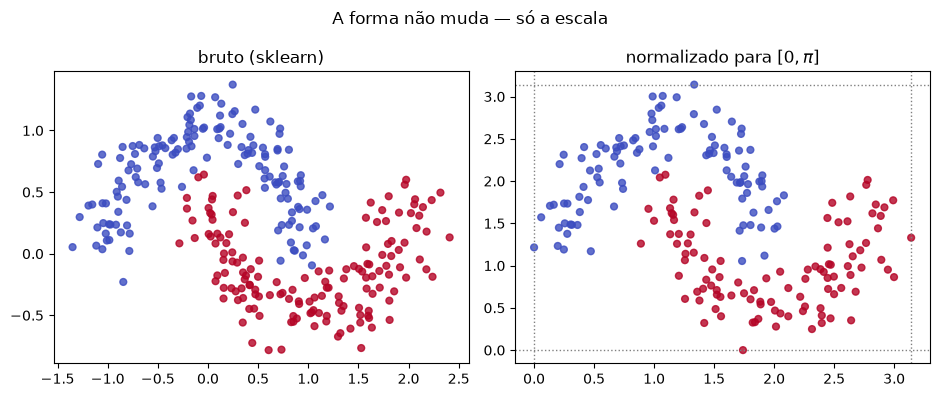

In [4]:
# mesmos valores do protocolo usados pelo load_dataset, para a comparação ser honesta
X_bruto, y_bruto = make_moons(
    n_samples=PADRAO.n_samples, noise=PADRAO.noise, random_state=PADRAO.seed
)
ds = datasets["moons"]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

axes[0].scatter(X_bruto[:, 0], X_bruto[:, 1], c=y_bruto, cmap="coolwarm", s=24, alpha=0.8)
axes[0].set_title("bruto (sklearn)")

axes[1].scatter(ds.X_train[:, 0], ds.X_train[:, 1], c=ds.y_train, cmap="coolwarm", s=24, alpha=0.8)
for v in (0, np.pi):
    axes[1].axhline(v, ls=":", lw=1, color="gray")
    axes[1].axvline(v, ls=":", lw=1, color="gray")
axes[1].set_title(r"normalizado para $[0,\pi]$")

fig.suptitle("A forma não muda — só a escala")
fig.tight_layout()
fig.savefig(FIGS / "01_normalizacao.png", dpi=150, bbox_inches="tight")
plt.show()

## Conferência numérica

Repare no `min_teste` e `max_teste`: eles saem **ligeiramente fora** de $[0, \pi]$.

Isso é correto e proposital. O `MinMaxScaler` é ajustado só no treino, então pontos de
teste mais extremos que qualquer ponto de treino extrapolam um pouco. Ajustar o scaler
no conjunto completo faria os limites baterem exatamente — e vazaria informação do teste
para o treino, inflando a acurácia. Número mais bonito, resultado inválido.

In [5]:
resumo = pd.DataFrame([
    {
        "dataset": nome,
        "treino": len(ds.X_train),
        "teste": len(ds.X_test),
        "frac_classe_1": round(float(ds.y_train.mean()), 3),
        "min_treino": round(float(ds.X_train.min()), 3),
        "max_treino": round(float(ds.X_train.max()), 3),
        "min_teste": round(float(ds.X_test.min()), 3),
        "max_teste": round(float(ds.X_test.max()), 3),
    }
    for nome, ds in datasets.items()
])
resumo

,dataset,treino,teste,frac_classe_1,min_treino,max_treino,min_teste,max_teste
0,xor,210,90,0.505,0.0,3.142,0.102,2.878
1,moons,210,90,0.500,0.0,3.142,-0.006,3.065
2,circles,210,90,0.500,0.0,3.142,-0.113,3.093


## Próximo passo

Com os dados no lugar, a Etapa 8 pede o classificador base: `embeddings.py` com
*angle encoding*, `ansatz.py`, e o modelo montando
$x \mapsto \psi(x) \mapsto U(\theta)\psi(x) \mapsto \langle Z_0 \rangle \mapsto \hat{y}$.

As figuras ficam em `results/figures/`, que não é versionado — regeneram rodando o notebook.